In [19]:
import numpy
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


class LinearOscillator:
    def __init__(self, freq=5, damping=0.1, dt=0.001):
        self.freq = freq
        self.damping = damping
        self.dt = dt
        self.state = None

    def reset(self, state_initial=None):
        if state_initial is None:
            self.state = numpy.array([1.0, 0.0])
        else:
            self.state = numpy.array(state_initial, dtype=float)
        return self.state

    def step(self, u=0.0):
        x1, x2 = self.state

        dx1 = x2
        dx2 = -self.damping * x2 - self.freq**2 * x1 + u

        self.state[0] += dx1 * self.dt
        self.state[1] += dx2 * self.dt

        return self.state


class NonlinearOscillator:
    def __init__(self, delta=0.1, omega=1.0, alpha=0.5, dt=0.001):
        self.delta = delta
        self.omega = omega
        self.alpha = alpha
        self.dt = dt
        self.state = None

    def reset(self, state_initial=None):
        if state_initial is None:
            self.state = numpy.array([1.0, 0.0])
        else:
            self.state = numpy.array(state_initial, dtype=float)
        return self.state

    def step(self):
        x1, x2 = self.state

        dx1 = x2
        dx2 = -self.delta * x2 - self.omega**2 * x1 - self.alpha * x1**2 

        self.state[0] += dx1 * self.dt
        self.state[1] += dx2 * self.dt

        return self.state


class DoubleInvertedPendulum:
    """
    Double pendulum with torque control input u at the first joint.
    
    Convention: 
        theta = 0 means vertically downward (hanging, stable equilibrium).
        Angles are measured from the downward vertical.
        The system naturally oscillates around theta = 0.
        For balancing control: apply torque u to stabilise near theta = 0.

    State: [theta1, theta2, dtheta1, dtheta2]
        theta1  - angle of first link from downward vertical (0 = hanging down)
        theta2  - angle of second link from downward vertical (0 = hanging down)
        dtheta1 - angular velocity of first link
        dtheta2 - angular velocity of second link

    Equations of motion (Lagrangian):

        M(q) ddq = f(q, dq, u)

        M = [ (m1+m2)*l1^2,       m2*l1*l2*cos(q1-q2) ]
            [ m2*l1*l2*cos(q1-q2), m2*l2^2              ]

        f1 = -(m1+m2)*g*l1*sin(q1) - m2*l1*l2*dq2^2*sin(q1-q2) - b1*dq1 + u
        f2 = -m2*g*l2*sin(q2)      + m2*l1*l2*dq1^2*sin(q1-q2) - b2*dq2

    Parameters:
        m1, m2  - masses of the two links (point masses at link tips)
        l1, l2  - lengths of the two links
        g       - gravitational acceleration
        b1, b2  - damping coefficients at joints
        dt      - integration time step
    """
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81, b1=0.01, b2=0.01, dt=0.001):
        self.m1 = m1
        self.m2 = m2
        self.l1 = l1
        self.l2 = l2
        self.g  = g
        self.b1 = b1
        self.b2 = b2
        self.dt = dt
        self.state = None

        # precompute how u maps to accelerations at equilibrium (theta=0)
        # M0^{-1} @ [1, 0]^T, where M0 is the mass matrix at equilibrium (cos_d=1)
        m11_0 = (m1 + m2) * l1**2
        m12_0 = m2 * l1 * l2
        m22_0 = m2 * l2**2
        det_0 = m11_0 * m22_0 - m12_0**2
        self.bu1 = m22_0 / det_0    # ddtheta1 per unit u
        self.bu2 = -m12_0 / det_0   # ddtheta2 per unit u

        self.B = numpy.array([[0], [0], [self.bu1], [self.bu2]])  # control input matrix for linearized system at equilibrium

    def reset(self, state_initial=None):
        if state_initial is None:
            # perturbation from downward equilibrium (theta=0 is hanging)
            self.state = numpy.array([0.5, 0.5, 0.0, 0.0])
        else:
            self.state = numpy.array(state_initial, dtype=float)
        return self.state

    def step(self, u=0.0):
        """
        Advance the state by one time step using Euler integration.
        u - torque applied at the first joint.

        Control u is separated from the nonlinear dynamics and applied
        as a linear state modifier using precomputed constants (bu1, bu2)
        from the mass matrix evaluated at equilibrium:
            ddtheta1 += bu1 * u
            ddtheta2 += bu2 * u
        """
        theta1, theta2, dtheta1, dtheta2 = self.state

        m1, m2 = self.m1, self.m2
        l1, l2 = self.l1, self.l2
        g = self.g
        b1, b2 = self.b1, self.b2

        delta = theta1 - theta2
        cos_d = numpy.cos(delta)
        sin_d = numpy.sin(delta)

        # Mass matrix M * [ddtheta1, ddtheta2] = f
        m11 = (m1 + m2) * l1**2
        m12 = m2 * l1 * l2 * cos_d
        m21 = m2 * l1 * l2 * cos_d
        m22 = m2 * l2**2

        # Right-hand side (no u here - pure autonomous nonlinear dynamics)
        f1 = -(m1 + m2) * g * l1 * numpy.sin(theta1) - m2 * l1 * l2 * dtheta2**2 * sin_d - b1 * dtheta1
        f2 = -m2 * g * l2 * numpy.sin(theta2) + m2 * l1 * l2 * dtheta1**2 * sin_d - b2 * dtheta2

        # Solve 2x2 system for autonomous part
        det = m11 * m22 - m12 * m21
        ddtheta1 = ( m22 * f1 - m12 * f2) / det
        ddtheta2 = (-m21 * f1 + m11 * f2) / det

        # Add control as linear state modifier (constants from M0^{-1} at equilibrium)
        ddtheta1 += self.bu1 * u
        ddtheta2 += self.bu2 * u

        # Euler integration
        self.state[0] += dtheta1 * self.dt
        self.state[1] += dtheta2 * self.dt
        self.state[2] += ddtheta1 * self.dt
        self.state[3] += ddtheta2 * self.dt

        return self.state


In [20]:
def plot_2d_trajectory(trajectory):
   
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(trajectory[:, 0], trajectory[:, 1])
    plt.show()

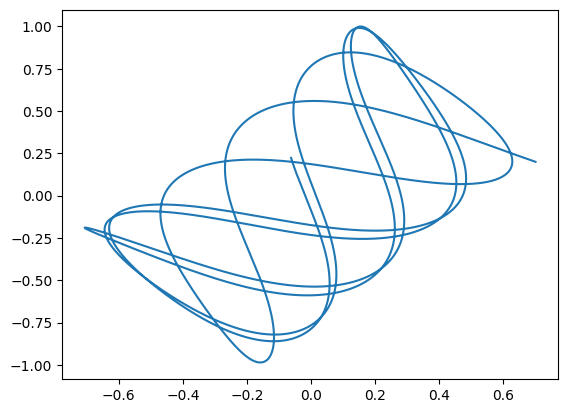

ref_trajectory (10000, 4)


In [21]:
num_steps = 10000
dt = 0.001
ref_trajectory = []

#env = LinearOscillator(dt=dt)
#env = NonlinearOscillator(dt=dt)
#initial_state = env.reset([1, 0]).copy()

# use larger initial angles to excite nonlinear dynamics
# small angles (e.g. 0.1 rad) keep the system near-linear (sin(x)~x), 
# use angles > 1 rad to see strong nonlinear behavior
env = DoubleInvertedPendulum(dt=dt)
initial_state = env.reset([0.7, 0.2, 0.0, 0.0])


for n in range(num_steps):
    state = env.step()
    ref_trajectory.append(state.copy())
    

ref_trajectory = numpy.array(ref_trajectory)

plot_2d_trajectory(ref_trajectory)

print("ref_trajectory", ref_trajectory.shape)


In [22]:
def plot_2d_trajectory_comp(ref_trajectory, pred_trajectory):
   
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(ref_trajectory[:, 0], ref_trajectory[:, 1], label='Reference', color='red', lw=2)
    ax.plot(pred_trajectory[:, 0], pred_trajectory[:, 1], label='Prediction', color='blue', lw=1)
    ax.legend()
    plt.show()

Error: 0.044733442616466564
(10000, 4)


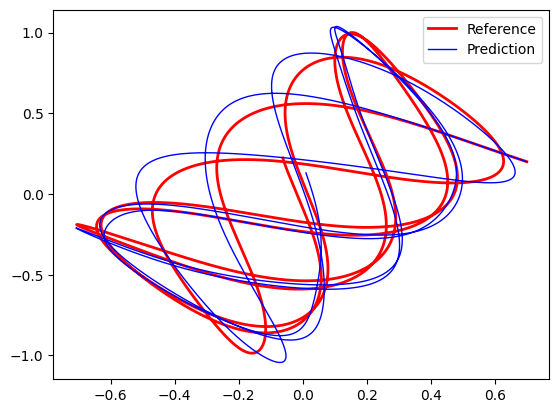

done


In [23]:
import AILibs

def hankel_lift(x, order):

    num_samples, num_states = x.shape
    lifted_samples = num_samples - order + 1

    Z = numpy.zeros((lifted_samples, num_states * order))

    for i in range(order):
        Z[:, i*num_states:(i+1)*num_states] = x[i:i+lifted_samples]

    return Z

lift_order = 3
z = hankel_lift(ref_trajectory, order=lift_order)


optimizer = AILibs.lr_fit

w = AILibs.system_identification_state(z, optimizer)

# Build proper initial lifted state from the first `order` trajectory points
num_states = ref_trajectory.shape[1]
z_initial = numpy.zeros((z.shape[1], 1))
for i in range(lift_order):
    z_initial[i*num_states:(i+1)*num_states, 0] = ref_trajectory[i]


predicted_trajectory = []
current_z = z_initial.copy()

for _ in range(num_steps):
    current_z = w@current_z
    predicted_trajectory.append(current_z[:ref_trajectory.shape[1], 0].copy())

predicted_trajectory = numpy.array(predicted_trajectory)

test_horizon = 1000
error = numpy.linalg.norm(ref_trajectory[0:test_horizon] - predicted_trajectory[0:test_horizon]) / numpy.linalg.norm(ref_trajectory)

print("Error:", error)
print(predicted_trajectory.shape)

plot_2d_trajectory_comp(ref_trajectory, predicted_trajectory)

print("done")

(12, 12) (12, 1) (12, 12) (1, 1)
[[ 1.47021963e-01 -2.79824849e-01  1.51271060e+03  1.51058735e+03
   1.65973256e+00  1.23076249e+00 -3.04054616e+03 -3.03498981e+03
  -1.38081360e+00 -1.80422732e+00  1.52824179e+03  1.52441158e+03]]


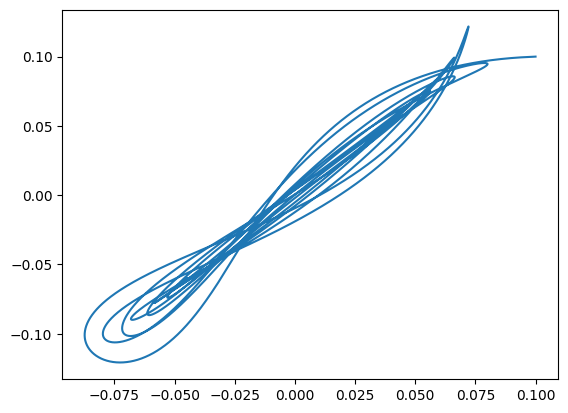

In [24]:
from KoopmanLQR import *

B    = env.B 

Q    = numpy.zeros((4, 4))
Q[0][0] = 1.0

R = numpy.zeros((1, 1))
R[0][0] = 1

klqr = KoopmanLQR(w, B, Q=numpy.eye(z.shape[1]), R=numpy.eye(1), lift_order=lift_order)



state = env.reset([0.1, 0.1, 0.0, 0.0]).copy()

klqr.reset()

predicted_trajectory = []

for _ in range(20000):
    u = klqr.forward(numpy.expand_dims(state, axis=1))
    state = env.step(u[0][0])
    predicted_trajectory.append(state.copy())   

predicted_trajectory = numpy.array(predicted_trajectory)
plot_2d_trajectory(predicted_trajectory)

#from animate_double_pendulum import animate_double_pendulum
#animate_double_pendulum(predicted_trajectory[::5, :], save_path="double_pendulum_klqr.gif")